In [197]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [198]:
df = pd.read_csv('/content/house_price_train.csv')
df_test = pd.read_csv('/content/house_price_test.csv')

In [199]:
print(df.shape)

(1460, 81)


In [200]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [201]:
print(df.isnull().sum().sum())

7829


In [202]:
print(f"{(df.isnull().sum() > 0).sum()} ta ustunda bo'sh qiymat mavjud")

19 ta ustunda bo'sh qiymat mavjud


In [203]:
features = df[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']]

corr = features.corr()

print(corr)

             OverallQual  GrLivArea  GarageCars  TotalBsmtSF
OverallQual     1.000000   0.593007    0.600671     0.537808
GrLivArea       0.593007   1.000000    0.467247     0.454868
GarageCars      0.600671   0.467247    1.000000     0.434585
TotalBsmtSF     0.537808   0.454868    0.434585     1.000000


In [204]:
print(df['SalePrice'].describe()) # mean > median ->  right scewd

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [205]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
1stFlrSF       0.605852
FullBath       0.560664
Name: SalePrice, dtype: float64


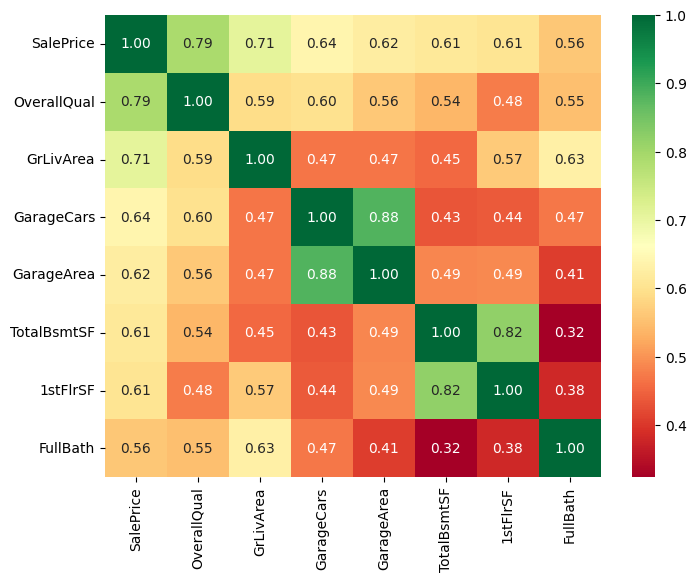

In [206]:
num = df.select_dtypes(include=["number"])

top_corr_features = num.corr()["SalePrice"].sort_values(ascending=False).head(8)
print(top_corr_features)

top_cols = top_corr_features.index

top_corr_matrix = num[top_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(top_corr_matrix, annot=True, cmap="RdYlGn", fmt=".2f")
plt.show()


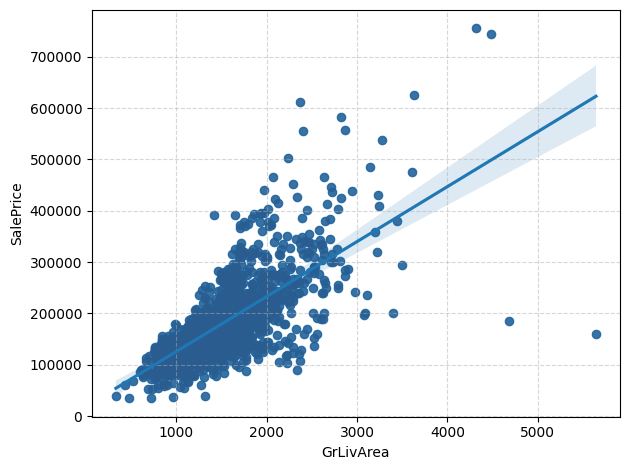

In [207]:
sns.regplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
)

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    color="#2b5c8f",
    alpha=0.6,
    edgecolor=None
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [208]:
null_percent = (df.isnull().sum() / len(df)) * 100
high_null_cols = null_percent[null_percent > 50].sort_values(ascending=False).round(2)

print(high_null_cols)

PoolQC         99.52
MiscFeature    96.30
Alley          93.77
Fence          80.75
MasVnrType     59.73
dtype: float64


In [209]:
# =================================== GrLivArea ===================================
X = df[["GrLivArea"]]
y = df["SalePrice"]

model = LinearRegression()
model.fit(X, y)

# y' = 107.13 * x + 18569.02
print(f"w -> {model.coef_[0]}")
print(f"b -> {model.intercept_}")
print(f"R^2 -> {model.score(X, y)}")
# w -> 107.13
# b -> 18569.02
# R^2 -> 0.50

w -> 107.1303589658252
b -> 18569.02585648722
R^2 -> 0.5021486502718042


In [210]:
new = pd.DataFrame({
    "GrLivArea": [1500, 2000]
})

p = model.predict(new)
print(p.round(0))
print((p[1] - p[0].round(0)))

[179265. 232830.]
53564.743788137625


In [211]:
# =================================== TotalBsmtSF ===================================
X = df[["TotalBsmtSF"]]

model = LinearRegression()
model.fit(X, y)

print(f"w -> {model.coef_[0]}")
print(f"b -> {model.intercept_}")
print(f"R^2 -> {model.score(X, y)}")
# w -> 111.10
# b -> 63430.62
# R^2 -> 0.38

w -> 111.10960368712762
b -> 63430.62854550623
R^2 -> 0.37648109325168655


In [212]:
def y(w, b, x):
  return w * x + b

print(y(111.10, 63430.62, 1000))
# 174530.62

174530.62


In [213]:
# =================================== YearBuilt ===================================
X = df[["YearBuilt"]]
y = df["SalePrice"]

model = LinearRegression()
model.fit(X, y)

print(f"w -> {model.coef_[0]}")
print(f"b -> {model.intercept_}")
print(f"R^2 -> {model.score(X, y)}")
# w -> 1375.37
# b -> -2530308.24
# R^2 -> 0.27

w -> 1375.3734679368924
b -> -2530308.2457323573
R^2 -> 0.27342162073249154


In [214]:
# =================================== OverallQual ===================================
X = df[["OverallQual"]]
y = df["SalePrice"]

model = LinearRegression()
model.fit(X, y)

print(f"w -> {model.coef_[0]}")
print(f"b -> {model.intercept_}")
print(f"R^2 -> {model.score(X, y)}")
# w -> 45435.80
# b -> -96206.08
# R^2 -> 0.62

w -> 45435.8025930994
b -> -96206.07951476038
R^2 -> 0.625651892462118


In [215]:
new = pd.DataFrame({
    "OverallQual": [7, 8]
})

p = model.predict(new)
print(p.round(0)) # [221845. 267280.]
print((p[1] - p[0].round(0))) # 45,435

[221845. 267280.]
45435.34123003483


In [216]:
has = (df["OverallQual"] == 1).sum()
print(has)

2


In [237]:
features = ["GrLivArea", "OverallQual", "GarageCars", "TotalBsmtSF", 'YearBuilt']
X = df[features]

In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

In [239]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, pred)
rmae = np.sqrt(mean_squared_error(y_test, pred))
mse = mean_squared_error(y_test, pred)
r2s = r2_score(y_test, pred)

print(f'mae -> {mae:.4f}')
print(f'r2s -> {r2s:.4f}')
print(f'mse -> {mse:.4f}')
print(f'rmae -> {rmae:.4f}')

# rmae >= mae

mae -> 25414.7254
r2s -> 0.7939
mse -> 1581119650.3936
rmae -> 39763.2953


In [233]:
from sklearn.dummy import DummyRegressor

dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)

y_pred = dummy_regr.predict(X_test)

In [221]:
mae = mean_absolute_error(y_test, y_pred)
rmae = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
r2s = r2_score(y_test, y_pred)

print(f'mae -> {mae:.2f}')
print(f'r2s -> {r2s:.2f}')
print(f'mse -> {mse:.2f}')
print(f'rmae -> {rmae:.2f}')

mae -> 60333.72
r2s -> -0.01
mse -> 7173361979.08
rmae -> 84695.70


In [242]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

In [243]:
r2s = r2_score(y_test, pred)
print(f'r2s -> {r2s:.4f}')

r2s -> 0.7939
